In [1]:
from cosipy import BinnedData, UnBinnedData#, COSILike
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.PointSourceResponse import PointSourceResponse

from COSILikeNew import COSILike

from scoords import SpacecraftFrame

import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit, minimize
from lmfit import Model
from lmfit.models import GaussianModel

from threeML import Gaussian, Cauchy, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter
from histpy import Histogram, Axes, Axis, HealpixAxis

from pathlib import Path

import os

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

14:54:38 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=383266;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=743927;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=880302;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=320429;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


14:54:39 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=735470;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=618387;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=363585;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=507148;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=363343;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=281621;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=713886;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=406078;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=308114;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=60645;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=143879;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=21679;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
DATA_DIR = Path('/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/')
DC2_DATA_DIR = Path('/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/tutorials/data')

### Background

In [42]:
# To extract binned data

bg = BinnedData("inputs.yaml")

In [ ]:
# # WIDE ENERGY BIN
# # Extraction only needs to be done once
# bg.data_file = str(DATA_DIR / 'data/backgrounds/unbinned/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits')
# bg.time_bins = 86400*93       # Full 3 month width
# bg.energy_bins = [1143., 1171.]       # DC2 response width
# bg.get_binned_data(unbinned_data = bg.data_file, 
#                          output_name = DATA_DIR / 'data/backgrounds/binned/albedo_photons_DC2')

In [43]:
bg.data_file = DATA_DIR / 'data/backgrounds/binned/albedo_photons_DC2.hdf5'

bg.load_binned_data_from_hdf5(bg.data_file)

In [44]:
bg.binned_data.axes['Time'].edges

<Quantity [1.8354780e+09, 1.8435132e+09] s>

### Source

In [74]:
# To play with unbinned data

name = 'CasAfullyresolved'
source = UnBinnedData("inputs.yaml")
source.data_file = str(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')

In [75]:
this_dict = source.get_dict_from_fits(source.data_file)

In [76]:
# To extract binned data
src = BinnedData("inputs.yaml")
src.data_file = str(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')
src.time_bins = 86400*93       # Full 3 month width
src.energy_bins = [1143., 1171.]       # DC2 response width

In [ ]:
# # WIDE ENERGY BIN
# # Extraction only needs to be done once
# src.get_binned_data(unbinned_data = src.data_file, 
#                          output_name = DATA_DIR / f'44Ti/sources/{name}_DC2')

In [78]:
src.load_binned_data_from_hdf5(DATA_DIR / f'44Ti/sources/{name}_DC2.hdf5')

In [79]:
src.binned_data.axes['Time'].edges

<Quantity [1.8354780e+09, 1.8435132e+09] s>

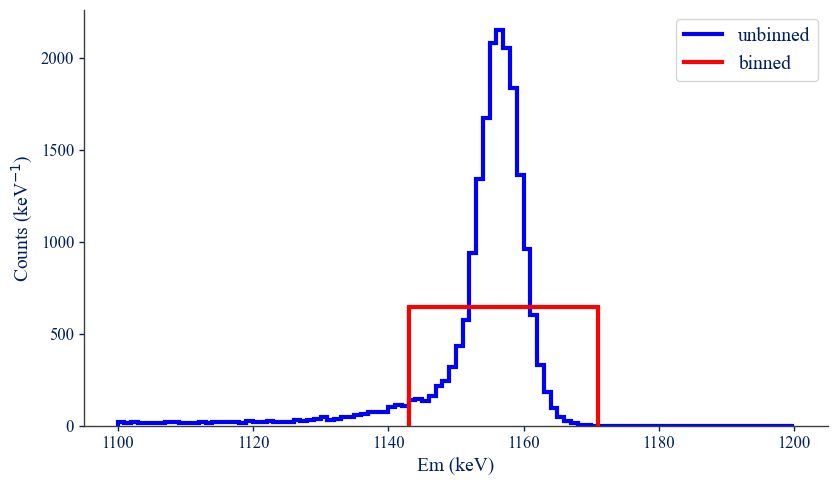

In [22]:
counts, bins = np.histogram(this_dict['Energies'], bins=np.linspace(1100, 1200, 101))
plt.stairs(counts/np.diff(bins), bins, label='unbinned', lw=3)

counts = src.binned_data.project('Em').todense().contents
bins = src.binned_data.axes['Em'].edges.value
plt.stairs(counts/np.diff(bins), bins, lw=3, label='binned')

plt.xlabel('Em (keV)')
plt.ylabel('Counts (keV$^{-1}$)')
plt.legend(fontsize=14)
plt.show()

### Response

In [ ]:
# # .rsp.gz --> .h5 conversion only needs to be run once
# response_filename = DATA_DIR / 'data/responses/SMEXv12.44Ti.HEALPix04.E_1143_1171keV.binnedimaging.imagingresponse.nonsparse.rsp.gz'

# # A minor edit to support Path-based filenames
# nside = 16
# # response_filename.replace(".rsp.gz","_nside{0}.area.h5".format(nside))    # Line 510
# str(response_filename).replace(".rsp.gz", "_nside{0}.area.h5".format(nside))

# with FullDetectorResponse.open(str(response_filename)) as response:
#     print(response.filename)

In [25]:
response_filename = DATA_DIR / 'data/responses/SMEXv12.44Ti.HEALPix04.E_1143_1171keV.binnedimaging.imagingresponse.nonsparse_nside16.area.h5'

with FullDetectorResponse.open(response_filename) as response:
    print(repr(response))

FILENAME: '/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/data/responses/SMEXv12.44Ti.HEALPix04.E_1143_1171keV.binnedimaging.imagingresponse.nonsparse_nside16.area.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 3072
    NSIDE: 16
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [1150.0 keV, 1164.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [1150.0 keV, 1164.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 60
    EDGES: [0.0 deg, 3.0 deg, 6.0 deg, 9.0 deg, 12.0 deg, 15.0 deg, 18.0 deg, 21.0 deg, 24.0 deg, 27.0 deg, 30.0 deg, 33.0 deg, 36.0 deg, 39.0 deg, 42.0 deg, 45.0 deg, 48.0 deg, 51.0 deg, 54.0 deg, 57.0 deg, 60.0 deg, 63.0 deg, 66.0 deg, 69.0 deg, 72.0 deg, 75.0 deg, 78.0 deg, 81.0 deg, 84.0 deg, 87.0

In [14]:
with FullDetectorResponse.open(response_filename) as response:
    dr = response[1300]

#### DC2 Narrow vs Wide Response Comparison

In [ ]:
psr_wide = Histogram.open(DC2_DATA_DIR / 'psr_gal_Ti44_E_1143_1171keV_DC2.h5')

In [ ]:
psr_narrow = Histogram.open(DC2_DATA_DIR / 'psr_gal_Ti44_E_1150_1164keV_DC2.h5')

In [ ]:
psr_wide.axes['Em'].edges, psr_narrow.axes['Em'].edges

(<Quantity [1150., 1164.] keV>, <Quantity [1150., 1164.] keV>)

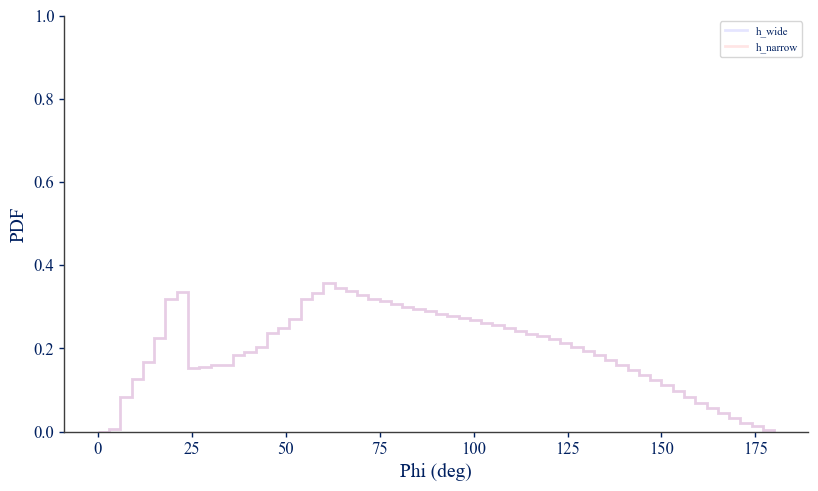

In [ ]:
h_wide = psr_wide.project('Phi')
h_narrow = psr_narrow.project('Phi')

for h, label in zip([h_wide, h_narrow], ['h_wide', 'h_narrow']):
    xdata = h.axes['Phi'].edges
    ydata = h.contents
    plt.stairs(ydata / ydata.sum() / np.diff(np.deg2rad(xdata)) / 1.6, xdata.value, alpha=0.1, lw=2, label=label)        # 1.6 factor from normalization analysis of unbinned source data

plt.xlabel('Phi (deg)')
plt.ylabel('PDF')
plt.ylim([0, 1])
plt.legend()
plt.show()

### Spacecraft Attitude and Orientation

In [3]:
ori_path = DATA_DIR / 'data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth.ori'
response_path = DATA_DIR / 'data/responses/SMEXv12.44Ti.HEALPix04.E_1143_1171keV.binnedimaging.imagingresponse.nonsparse_nside16.area.h5'

In [4]:
# define the target coordinates (Cas A)
target_coord = SkyCoord.from_name('Cas A').galactic

In [5]:
# read the full oritation
ori = SpacecraftFile.parse_from_file(ori_path)

#### ScAtt Map

In [6]:
scatt_map = ori.get_scatt_map(nside = 16, coordsys = 'galactic')

In [ ]:
# # Only needs to be created once
# with FullDetectorResponse.open(response_path) as response:
#     psr_scatt = response.get_point_source_response(coord = target_coord, scatt_map = scatt_map)

# psr_scatt.write('psr_DC2_scatt_hist.h5')

In [ ]:
hist = Histogram.open('psr_DC2_scatt_hist.h5')

# TODO: Need functionality to load PSR from .h5 file
psr_scatt = PointSourceResponse(hist.axes,
                                contents=hist.contents,
                                sparse=hist._sparse,
                                unit=hist.unit)

In [ ]:
new_axes = []

for axis in hist.axes[:2]:
    new_axes += [Axis(np.array(src.energy_bins) * u.keV,
                    label = axis.label,
                    scale = axis.axis_scale)]

axis = hist.axes[2]
new_axes += [Axis(axis.edges, label = axis.label,
                  scale = axis.axis_scale)]

axis = hist.axes[3]
new_axes += [HealpixAxis(edges=np.array(axis),
                         nside=axis.nside,
                         label=axis.label,
                         scheme=axis.scheme,
                         coordsys=axis.coordsys)]

NameError: name 'hist' is not defined

In [ ]:
psr_scatt = PointSourceResponse(new_axes,
                                contents=hist.contents,
                                sparse=hist._sparse,
                                unit=hist.unit)

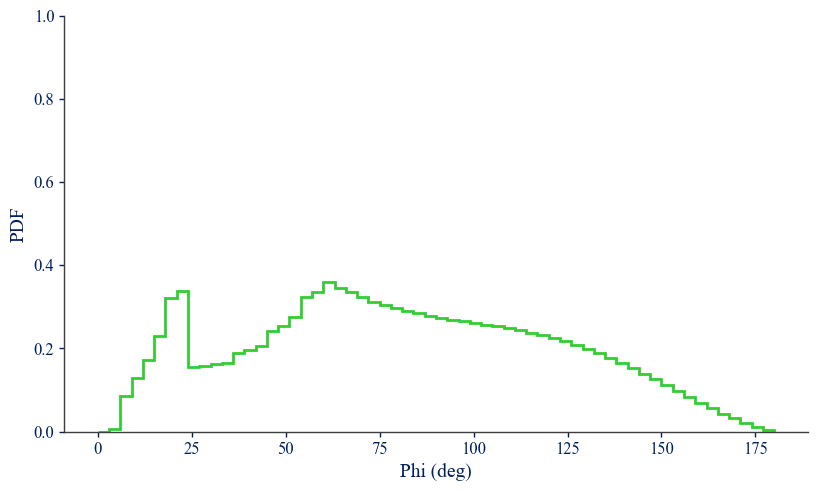

In [ ]:
h = psr_scatt.project('Phi')

xdata = h.axes['Phi'].edges
ydata = h.contents
plt.stairs(ydata / ydata.sum() / np.diff(np.deg2rad(xdata)) / 1.6, xdata.value, edgecolor='limegreen', lw=2)        # 1.6 factor from normalization analysis of unbinned source data

plt.xlabel('Phi (deg)')
plt.ylabel('PDF')
plt.ylim([0, 1])
plt.show()      # Not very different existing psr maps

In [ ]:
# TODO: How do you increase the width of the Em and Ei bin and accordingly re-normalize the contents?

###### Sanity Check

In [113]:
psr_scatt.axes['PsiChi'].coordsys, psr_scatt.contents.unit

(<Galactic Coordinate: (l, b) in deg
     (111.73761886, -2.13450707)>,
 Unit("cm2 s"))

In [19]:
F = 1e-5 * u.ph / u.cm / u.cm / u.s
mu = 1157 * u.keV
sigma = 5 * u.keV

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value 
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.unit = sigma.unit

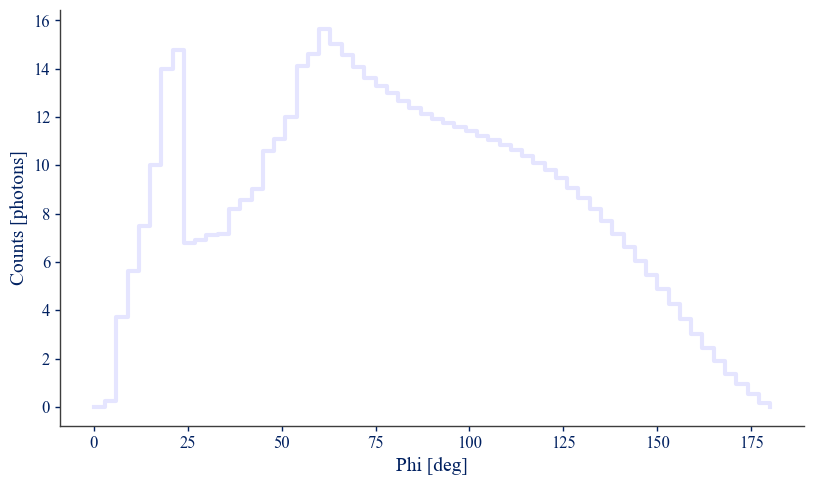

In [21]:
expectation = psr_scatt.get_expectation(spectrum)
ax, plot = expectation.project('Phi').plot(alpha=0.1)

plt.ylabel('Counts [photons]')
plt.show()

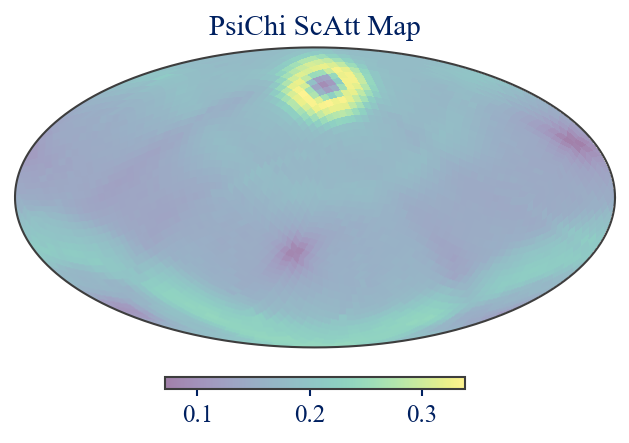

In [22]:
expectation = psr_scatt.get_expectation(spectrum)
ax, plot = expectation.project('PsiChi').plot(alpha=0.5)

ax.set_title('PsiChi ScAtt Map', fontsize=14)
plt.show()

In [39]:
import gzip
response_filename = DATA_DIR / 'data/responses/SMEXv12.44Ti.HEALPix04.E_1143_1171keV.binnedimaging.imagingresponse.nonsparse.rsp.gz'

labels = ("Ei", "NuLambda", "Em", "Phi", "PsiChi", "SigmaTau", "Dist")

axes_edges = []
axes_types = []
sparse = None

with gzip.open(response_filename, "rt") as file:
    for n, line in enumerate(file):

        line = line.split()

        if len(line) == 0:
            continue

        key = line[0]

        if key == 'AD':

            if axes_types[-1] == "FISBEL":

                raise RuntimeError("FISBEL binning not currently supported")
                
            elif axes_types[-1] == "HEALPix":

                if line[2] != "RING":
                    raise RuntimeError(f"Scheme {line[2]} not supported")

                if line[1] == '-1':
                    # Single bin axis --i.e. all-sky
                    axes_edges.append(-1)
                else:
                    nside = int(2**int(line[1]))
                    axes_edges.append(int(12*nside**2))
                
                
            else:
                
                axes_edges.append(np.array(line[1:], dtype='float'))

        elif key == 'AT':
            axes_types += [line[2]]
        
        elif key == "StartStream":
            nbins = int(line[1])
            break

axes_edges

[array([1150., 1164.]),
 3072,
 array([1150., 1164.]),
 array([  0.,   3.,   6.,   9.,  12.,  15.,  18.,  21.,  24.,  27.,  30.,
         33.,  36.,  39.,  42.,  45.,  48.,  51.,  54.,  57.,  60.,  63.,
         66.,  69.,  72.,  75.,  78.,  81.,  84.,  87.,  90.,  93.,  96.,
         99., 102., 105., 108., 111., 114., 117., 120., 123., 126., 129.,
        132., 135., 138., 141., 144., 147., 150., 153., 156., 159., 162.,
        165., 168., 171., 174., 177., 180.]),
 3072,
 -1,
 array([   0., 1000.])]

### Spectral Fitting

In [40]:
F = 1e-4 / u.cm / u.cm / u.s
mu = 1157 * u.keV
sigma = 5 * u.keV

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.min_value = F.value / 1e3
spectrum.F.max_value = F.value * 1e3
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value 
spectrum.mu.min_value = mu.value - 10
spectrum.mu.max_value = mu.value + 10
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.min_value = sigma.value - 5
spectrum.sigma.max_value = sigma.value + 5
spectrum.sigma.unit = sigma.unit

In [80]:
# Set background parameter, which is used to fit the amplitude of the background
# For now, this is just a normalization parameter
bg_par = Parameter("background_cosi",                                         # background parameter
                     2.4,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

# Create COSI 3ML plug-in - COSILike (defined in cosipy)
data = src.binned_data.project('Em', 'Phi', 'PsiChi') + bg.binned_data.project('Em', 'Phi', 'PsiChi')

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = response_path,                                           # detector response
                 data = data,        # data (source+background)
                #  bkg = Histogram(hist_SAA.axes),                               # background model (zero)
                 bkg = bg.binned_data.project('Em', 'Phi', 'PsiChi'),         # background model 
                 nuisance_param = bg_par,                                     # background parameter
                 sc_orientation = ori,                              # spacecraft orientation
                 coordsys = 'galactic',
                 precomputed_psr_file = 'psr_scatt_SAA_hist.h5')

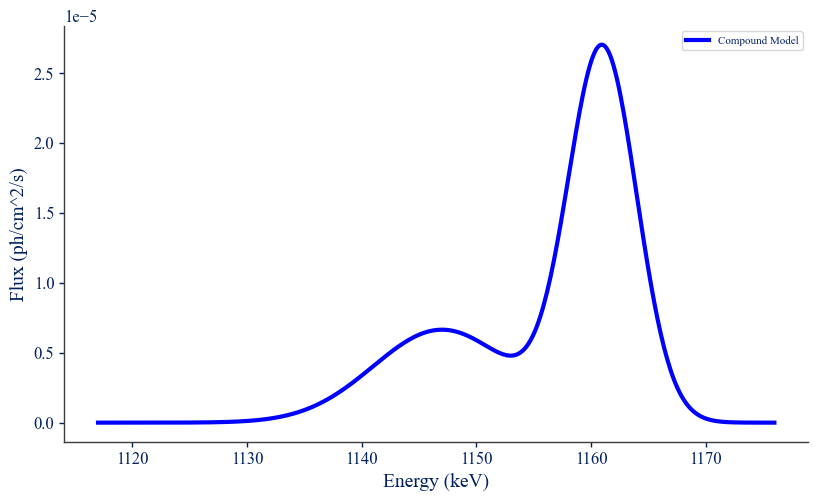

In [81]:
# Define the first Gaussian
F1 = 1e-4 / u.cm / u.cm / u.s
mu1 = (1157-10) * u.keV
sigma1 = 6 * u.keV

gaussian1 = Gaussian()
gaussian1.F.value = F1.value
gaussian1.F.min_value = F1.value / 1e3
gaussian1.F.max_value = F1.value * 1e3
gaussian1.F.unit = F1.unit
gaussian1.mu.value = mu1.value
gaussian1.mu.min_value = mu1.value - 10
gaussian1.mu.max_value = mu1.value + 10
gaussian1.mu.unit = mu1.unit
gaussian1.sigma.value = sigma1.value
gaussian1.sigma.min_value = sigma1.value - 5
gaussian1.sigma.max_value = sigma1.value + 5
gaussian1.sigma.unit = sigma1.unit

# Define the second Gaussian
F2 = 2e-4 / u.cm / u.cm / u.s
mu2 = (1157+4) * u.keV
sigma2 = 3 * u.keV

gaussian2 = Gaussian()
gaussian2.F.value = F2.value
gaussian2.F.min_value = F2.value / 1e3
gaussian2.F.max_value = F2.value * 1e3
gaussian2.F.unit = F2.unit
gaussian2.mu.value = mu2.value
gaussian2.mu.min_value = mu2.value - 10
gaussian2.mu.max_value = mu2.value + 10
gaussian2.mu.unit = mu2.unit
gaussian2.sigma.value = sigma2.value
gaussian2.sigma.min_value = sigma2.value - 5
gaussian2.sigma.max_value = sigma2.value + 5
gaussian2.sigma.unit = sigma2.unit

# Create the compound model
compound_model = gaussian1 + gaussian2

# Generate some data for plotting
x_data = np.linspace(mu1.value - 5 * sigma1.value, mu2.value + 5 * sigma2.value, 400)
y_data = compound_model(x_data)

# Plot the compound model
plt.plot(x_data, y_data, label="Compound Model")
plt.xlabel("Energy (keV)")
plt.ylabel("Flux (ph/cm^2/s)")
plt.legend()
plt.show()

In [82]:
compound_model.__dict__

{'_calling_sequence': ('+',
    * description: A Gaussian function
    * formula: $ K \frac{1}{\sigma \sqrt{2 \pi}}\exp{\frac{(x-\mu)^2}{2~(\sigma)^2}} $
    * parameters:
      * F_1:
        * value: 0.0001
        * desc: Integral between -inf and +inf. Fix this to 1 to obtain a Normal distribution
        * min_value: 1.0000000000000001e-07
        * max_value: 0.1
        * unit: s-1 cm-2
        * is_normalization: false
        * delta: 0.1
        * free: true
      * mu_1:
        * value: 1147.0
        * desc: Central value
        * min_value: 1137.0
        * max_value: 1157.0
        * unit: keV
        * is_normalization: false
        * delta: 0.1
        * free: true
      * sigma_1:
        * value: 6.0
        * desc: standard deviation
        * min_value: 1.0
        * max_value: 11.0
        * unit: keV
        * is_normalization: false
        * delta: 0.1
        * free: true,
    * description: A Gaussian function
    * formula: $ K \frac{1}{\sigma \sqrt{2 \pi}

In [83]:
CasA_model = PointSource('CasA', spectral_shape=compound_model,      # spectrum or compound_model
                           l=target_coord.l.value,
                           b=target_coord.b.value)

In [84]:
threeml_model = Model(CasA_model)

In [85]:
cosi.set_model(threeml_model)
plugins = DataList(cosi)
like = JointLikelihood(threeml_model, plugins, verbose = False)

15:53:09 INFO      set the minimizer to minuit                                             ]8;id=607967;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=624528;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

In [86]:
like.fit()

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


15:53:16 WARNING   get_number_of_data_points not implemented, values for statistical        ]8;id=480806;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/plugin_prototype.py\plugin_prototype.py]8;;\:]8;id=703690;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/plugin_prototype.py#130\130]8;;\
                  measurements such as AIC or BIC are unreliable                                                   

         WARNING   83.96000000000001 percent of samples have been thrown away because they ]8;id=584273;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=883527;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py#1740\1740]8;;\
                  failed the constraints on the parameters. This results might not be                              
                  suitable for error propagation. Enlarge the boundaries until you loose                           
                  less than 1 percent of the samples.                                                              

15:53:16 WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.1.     ]8;id=292844;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=158811;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum 1137.0. ]8;id=169430;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=932678;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,33428.844209
total,33428.844209


Values of statistical measures:

,statistical measures
AIC,66855.688419
BIC,66857.688419


(                                            value  negative_error  \
 CasA.spectrum.main.composite.F_1         0.001277       -0.000224   
 CasA.spectrum.main.composite.mu_1     1149.394037       -1.935474   
 CasA.spectrum.main.composite.sigma_1     8.555597       -4.946203   
 CasA.spectrum.main.composite.F_2         0.000368       -0.000145   
 CasA.spectrum.main.composite.mu_2     1158.776860       -4.247178   
 CasA.spectrum.main.composite.sigma_2     7.490440       -3.242567   
 background_cosi                          0.998210       -0.002129   
 
                                       positive_error     error         unit  
 CasA.spectrum.main.composite.F_1            0.000162  0.000193  1 / (s cm2)  
 CasA.spectrum.main.composite.mu_1           1.012067  1.473771          keV  
 CasA.spectrum.main.composite.sigma_1        1.271133  3.108668          keV  
 CasA.spectrum.main.composite.F_2            0.000085  0.000115  1 / (s cm2)  
 CasA.spectrum.main.composite.mu_2         

In [87]:
# Summary of results
results = like.results

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model['CasA'].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model['CasA'].spectrum.main.shape.evaluate_at, **parameters)

15:53:25 WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.1.     ]8;id=468567;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=719471;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum 1137.0. ]8;id=605088;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=637949;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.2.     ]8;id=818081;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=820096;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum 1151.0. ]8;id=286626;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=731099;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

         WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.1.     ]8;id=449392;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=718946;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum 1137.0. ]8;id=99833;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=460622;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.2.     ]8;id=114696;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=61484;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum 1151.0. ]8;id=335369;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=829327;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

In [88]:
results.display()

Best fit values:

,result,unit
parameter,,
CasA.spectrum.main.composite.F_1,(1.28 +/- 0.20) x 10^-3,1 / (s cm2)
CasA.spectrum.main.composite.mu_1,(1.1494 +/- 0.0016) x 10^3,keV
CasA.spectrum.main.composite.sigma_1,9 +/- 6,keV
CasA.spectrum.main.composite.F_2,(3.7 +/- 1.3) x 10^-4,1 / (s cm2)
CasA.spectrum.main.composite.mu_2,(1.159 +/- 0.013) x 10^3,keV
CasA.spectrum.main.composite.sigma_2,7.5 +/- 2.6,keV
background_cosi,(9.982 +/- 0.022) x 10^-1,


Correlation matrix:

1.00,-0.18,0.18,-0.16,0.25,0.18,-0.00
-0.18,1.00,0.18,-0.16,0.25,0.18,-0.00
0.18,0.18,1.00,0.18,-0.29,-0.21,0.00
-0.16,-0.16,0.18,1.00,0.26,0.19,-0.00
0.25,0.25,-0.29,0.26,1.00,-0.11,0.01
0.18,0.18,-0.21,0.19,-0.11,1.00,0.00
-0.00,-0.00,0.00,-0.00,0.01,0.00,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,33428.844209
total,33428.844209


Values of statistical measures:

,statistical measures
AIC,66855.688419
BIC,66857.688419


In [89]:
energy = np.linspace(src.energy_bins[0], src.energy_bins[-1], 113)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)

# Evaluate flux
for i, e in enumerate(energy):
    flux = results_err(e)
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_median[i] = flux.median

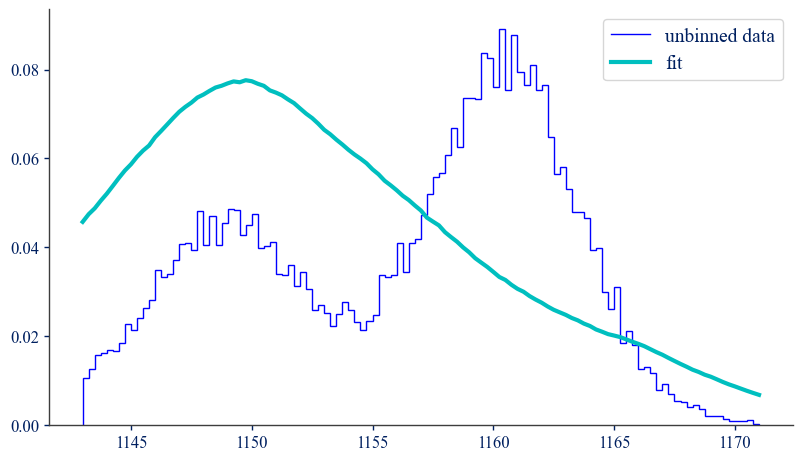

In [99]:
counts, _ = np.histogram(this_dict['Energies'], bins=energy)
plt.stairs(counts/counts.sum()/np.diff(energy), energy, label='unbinned data')

plt.plot(energy, flux_median*1e3, c='c', label='fit')
# plt.yscale('log')
plt.legend(fontsize=14)
plt.show()